In [1]:

import os
import sys
import argparse
import datetime
import numpy as np
import time
import torch
import torch.backends.cudnn as cudnn
import json
from pathlib import Path
from collections import OrderedDict
from functools import partial

# Add project root to path
# sys.path.insert(0, str(Path(__file__).parent))

from timm.models import create_model
from timm.loss import LabelSmoothingCrossEntropy, SoftTargetCrossEntropy
from timm.scheduler import create_scheduler
from src.optim.optim_factory import create_optimizer, get_parameter_groups, LayerDecayValueAssigner

from timm.utils import ModelEma

from src.utils.config import get_cfg, merge_config_file, freeze_cfg, load_and_freeze_config
from src.engine.train_engine import TrainingEngine
from src.engine.val_engine import ValidationEngine
from src.utils.evaluation import merge_distributed_results
from src.optim.mixup import Mixup
# from src.optim.optim_factory import LayerDecayValueAssigner
from src.dataset.datasets import build_dataset
from src.utils.utils import NativeScalerWithGradNormCount as NativeScaler
from src.utils.utils import multiple_samples_collate
from src.utils.logger import TensorboardLogger
from src.utils import utils

from src.models import ViT, ViT_pretrain, layers

from run_finetuning_with_yacs import create_data_loaders, create_model_from_config

/root/miniconda3/envs/mamba/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/miniconda3/envs/mamba/lib/python3.12/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/root/miniconda3/envs/mamba/lib/python3.12/site-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [2]:
config_path = '/home/qzk/Facial-Foundation-Model/output/dfew_T_0_debug_2/config.yaml'
cfg = get_cfg()
merge_config_file(cfg, config_path)
cfg.SYSTEM.DISTRIBUTED = False  # Disable distributed training
# cfg.batch_size = 2  # Set batch size to 2
data_loader_train, data_loader_val = create_data_loaders()

Found 9354 CSV files in /home/qzk/Facial-Foundation-Model/saved/data/dfew_combine/split01/train
Loaded 9354 CSV files with 9354 valid clips
Number of the class = 7
Found 2340 CSV files in /home/qzk/Facial-Foundation-Model/saved/data/dfew_combine/split01/val
Loaded 2340 CSV files with 2340 valid clips
Number of the class = 7


In [3]:
model = create_model_from_config()

==> Note: Use 'local_global' for compute reduction (lg_region_size=[2, 2, 10],lg_first_attn_type=self, lg_third_attn_type=cross,lg_attn_param_sharing_first_third=False,lg_attn_param_sharing_all=False,lg_classify_token_type=org,lg_no_second=False, lg_no_third=False)
==> Number of local regions: 20 (size=[4, 5, 1])
model after create_model = VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv3d(3, 512, kernel_size=(2, 16, 16), stride=(2, 16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0): LGBlock(
      (first_attn_norm0): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
      (first_attn): GeneralAttention(
        (q): Linear(in_features=512, out_features=512, bias=False)
        (kv): Linear(in_features=512, out_features=1024, bias=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=512, out_features=512, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (second_a

In [4]:
model_path = "/home/qzk/Facial-Foundation-Model/output/dfew_T_debug_2/checkpoint-99.pth"
state_dict = torch.load(model_path, map_location='cpu', weights_only=False)
state_dict = state_dict["model"]
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

<All keys matched successfully>

In [6]:
# pick a sample from the training set
samples, targets, _, _ = next(iter(data_loader_train))

# for i in range(10):
# samples, targets, _ = next(iter(data_loader_val))

print(samples.shape, targets.shape)
# visualize the model output for the sample
with torch.no_grad():
    model.eval()
    print("shape of sample:", samples.shape)
    output = model(samples)
    output_emo = output["cls"]
    output_gaze = output["reg"]
    print("shape of output_emo", output_emo.shape)
    print("shape of output_gaze", output_gaze.shape)
    output_emo = output_emo.reshape(-1, cfg.DATA.NUM_FRAMES, cfg.DATA.NUM_CLASSES)
    output_gaze = output_gaze.reshape(-1, cfg.DATA.NUM_FRAMES,2)
    
    
    
    # targets = targets.reshape(-1, cfg.DATA.NUM_FRAMES, 2)
    # output = output.reshape(-1, cfg.DATA.NUM_FRAMES, 2)
    
target_reg = targets[...,1:]
target_cls = targets[...,0].long()
target_reg = target_reg.reshape(-1, 2)
output_gaze = output_gaze.reshape(-1, 2)
print("target_reg like", target_reg)
print("output_gaze like", output_gaze)
loss = torch.nn.functional.mse_loss(output_gaze, target_reg)
print("loss: ", loss.item())
from src.utils.gaze import compute_angular_error
angular_error = compute_angular_error(output_gaze, target_reg)
print("angular_error: ", angular_error.item())
target_reg = target_reg.reshape(-1, cfg.DATA.NUM_FRAMES, 2)
output_gaze = output_gaze.reshape(-1, cfg.DATA.NUM_FRAMES, 2)
print("output_gaze.shape ", output_gaze.shape)
print("target_reg.shape ", target_reg.shape)



# [DEBUG], try this!
bsz = samples.shape[0]
cls_pred = output_emo.reshape(bsz, -1, cfg.DATA.NUM_CLASSES)
cls_pred = cls_pred.mean(1)
cls_tar = target_cls.reshape(bsz, -1)
cls_tar = cls_tar[:,0]
    

target_cls = cls_tar.reshape(-1)
output_emo = cls_pred.reshape(-1, cfg.DATA.NUM_CLASSES)
print("output_emo ", output_emo)
print("target_cls ", target_cls)
loss = torch.nn.functional.cross_entropy(output_emo, target_cls)
print("loss: ", loss.item())
acc = (output_emo.argmax(dim=-1) == target_cls).float().mean()
print("acc: ", acc.item())
# target_cls = target_cls.reshape(-1, cfg.DATA.NUM_FRAMES)
# output_emo = output_emo.reshape(-1, cfg.DATA.NUM_FRAMES, cfg.DATA.NUM_CLASSES)
print("target_cls shape", target_cls.shape)


torch.Size([32, 3, 16, 160, 160]) torch.Size([32, 16, 3])
shape of sample: torch.Size([32, 3, 16, 160, 160])
==> in VisionTransformer forward
==> Local-Global attention mode
 Local-Global attention: nt=4, t=2, nh=5, h=2, nw=1, w=10, b=32
shape of x after rearrange: torch.Size([32, 20, 40, 512])
shape of x after adding region tokens: torch.Size([32, 20, 41, 512])
shape of x after rearrange for blocks: torch.Size([640, 41, 512])
shape of x after block 0: torch.Size([640, 41, 512])
shape of x after block 1: torch.Size([640, 41, 512])
shape of x after block 2: torch.Size([640, 41, 512])
shape of x after block 3: torch.Size([640, 41, 512])
shape of x after block 4: torch.Size([640, 41, 512])
shape of x after block 5: torch.Size([640, 41, 512])
shape of x after block 6: torch.Size([640, 41, 512])
shape of x after block 7: torch.Size([640, 41, 512])
shape of x after block 8: torch.Size([640, 41, 512])
shape of x after block 9: torch.Size([640, 41, 512])
shape of x after block 10: torch.Size([

In [15]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# if target_angle.shape[1] == 3:
#     from src.utils.gaze import gaze3d_to_gaze2d
#     target_angle = gaze3d_to_gaze2d(target_angle)

for i, sample in enumerate(samples):
    print("sample shape:", sample.shape) # (3, 16, 160, 160)
    # record to a video file
    sample = sample.permute(1, 2, 3, 0)  # Change to (time, height, width, channels)
    sample = sample.detach().cpu().numpy()  # Convert to numpy array
    # add mean and std normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    sample = (sample * std + mean)  # Denormalize
    sample = np.clip(sample, 0, 1)  # Clip values to [0, 1]
    sample = (sample * 255).astype(np.uint8)  # Convert to uint8
    lbl = target_reg[i]
    pred = output_gaze[i]
    new_samples = []
    for j in range(sample.shape[0]):
        # Draw the target and output angles on each frame
        target_angle = lbl[j].numpy()
        output_angle = pred[j].numpy()
        
        pl0 = -np.cos(output_angle[0]) * np.sin(output_angle[1])
        pl1 = -np.sin(output_angle[0])
        
        new_sample = cv2.arrowedLine(sample[j].copy(), (80, 80), (int(80 + pl0 * 50), int(80 + pl1 * 50)), (0, 0, 255), 2, tipLength=0.1)
        
        ol0 = -np.cos(target_angle[0]) * np.sin(target_angle[1])
        ol1 = -np.sin(target_angle[0])
        
        # print(sample[j].shape, target_angle.shape)
        # print("type of sample[j]:", type(sample[j]))
        
        new_sample = cv2.arrowedLine(new_sample.copy(), (80, 80), (int(80 + ol0 * 50), int(80 + ol1 * 50)), (255, 0, 0), 2, tipLength=0.1)
        new_samples.append(new_sample)
        
    new_samples = np.array(new_samples)
    sample = new_samples  # Use the modified samples with arrows
        # cv2.arrowedLine(sample[j], (80, 80), (int(80 + ol0 * 50), int(80 + ol1 * 50)), (255, 0, 0), 2, tipLength=0.1)
    # sample = cv2.cvtColor(sample, cv2.COLOR_RGB2BGR)
    # record a video file
    video_path = f"output/data_debug/sample_video_{i}_pred{output_emo.argmax(dim=-1)[i]}_tar{target_cls[i]}.mp4"
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    height, width, _ = sample[0].shape
    out = cv2.VideoWriter(video_path, fourcc, 5.0, (width, height))
    for frame in sample:
        out.write(frame)
    out.release()
    print("video saved to:", video_path)

sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_0_pred1_tar1.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_1_pred8_tar8.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_2_pred6_tar6.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_3_pred5_tar5.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_4_pred4_tar4.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_5_pred10_tar10.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_6_pred3_tar3.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_7_pred1_tar1.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_8_pred5_tar5.mp4
sample shape: torch.Size([

0. Anger
1. Disgust
2. Fear
3. Happiness
4. Sadness
5. Surprised
6. Comtempt
7. Anxiety
8. Helplessness
9. Disappointment
10. Neutral

In [7]:
# Gradient-based Saliency Visualization
import torch.nn.functional as F

def compute_gradient_saliency(model, input_tensor, target_value, output_type='gaze', use_guided_backprop=True):
    """
    Compute gradient of output w.r.t. input with improved visualization
    Args:
        model: the model
        input_tensor: input tensor (requires_grad=True)
        target_value: target value for computing gradient
        output_type: 'gaze' or 'emo'
        use_guided_backprop: whether to use guided backpropagation
    Returns:
        saliency map
    """
    model.eval()
    input_tensor.requires_grad_(True)
    
    # Clear any existing gradients
    if input_tensor.grad is not None:
        input_tensor.grad.zero_()
    
    # Forward pass
    output = model(input_tensor)
    
    if output_type == 'gaze':
        # For gaze regression, use output magnitude instead of loss
        # This gives stronger gradients for visualization
        output_gaze = output["reg"]
        output_gaze = output_gaze.reshape(-1, cfg.DATA.NUM_FRAMES, 2)
        # Use L2 norm of prediction as the target to maximize
        target_magnitude = torch.norm(output_gaze, dim=-1).mean()
        loss = target_magnitude
    elif output_type == 'emo':
        # For emotion classification, use max logit
        output_emo = output["cls"]
        output_emo = output_emo.reshape(-1, cfg.DATA.NUM_FRAMES, cfg.DATA.NUM_CLASSES)
        bsz = input_tensor.shape[0]
        cls_pred = output_emo.reshape(bsz, -1, cfg.DATA.NUM_CLASSES).mean(1)
        # Use the maximum predicted class score
        max_score = torch.max(cls_pred, dim=-1)[0].mean()
        loss = max_score
    
    # Backward pass to compute gradients
    loss.backward()
    
    print(f"[DEBUG] grad of input_tensor {input_tensor.grad.shape}, range: [{input_tensor.grad.min():.6f}, {input_tensor.grad.max():.6f}]")
    
    # Get gradients w.r.t. input and enhance them
    saliency = input_tensor.grad.data.abs()  # Take absolute value
    
    # Enhance gradient visualization by normalizing per sample
    for i in range(saliency.shape[0]):
        sample_grad = saliency[i]
        # Normalize to [0, 1] range for better visualization
        sample_min = sample_grad.min()
        sample_max = sample_grad.max()
        if sample_max > sample_min:
            saliency[i] = (sample_grad - sample_min) / (sample_max - sample_min)
    
    return saliency, loss.item()

print("Gradient saliency computation function defined")

Gradient saliency computation function defined


In [10]:
def create_saliency_overlay(original_frames, saliency_map, alpha=0.6):
    """
    Create overlay of saliency map on original frames with improved visualization
    Args:
        original_frames: numpy array of shape (T, H, W, 3)
        saliency_map: numpy array of shape (T, H, W) 
        alpha: transparency of overlay
    Returns:
        overlayed frames
    """
    import matplotlib.cm as cm
    import scipy.ndimage as ndimage
    
    # Apply Gaussian smoothing to reduce patch artifacts
    smoothed_saliency = np.zeros_like(saliency_map)
    for t in range(saliency_map.shape[0]):
        # Smooth each frame to reduce grid patterns
        smoothed_saliency[t] = ndimage.gaussian_filter(saliency_map[t], sigma=2.0)
    
    # Enhance contrast using gamma correction
    gamma = 0.5  # Makes bright areas brighter
    saliency_enhanced = np.power(smoothed_saliency, gamma)
    
    # Normalize saliency map to [0, 1] with better dynamic range
    saliency_norm = np.zeros_like(saliency_enhanced)
    for t in range(saliency_enhanced.shape[0]):
        frame_sal = saliency_enhanced[t]
        # Use percentile normalization for better contrast
        p5, p95 = np.percentile(frame_sal, [5, 95])
        if p95 > p5:
            frame_sal_norm = np.clip((frame_sal - p5) / (p95 - p5), 0, 1)
        else:
            frame_sal_norm = frame_sal
        saliency_norm[t] = frame_sal_norm
    
    # Apply colormap (hot colormap for saliency)
    colormap = cm.get_cmap('hot') if hasattr(cm, 'get_cmap') else plt.cm.hot
    saliency_colored = colormap(saliency_norm)[:, :, :, :3]  # Remove alpha channel
    saliency_colored = (saliency_colored * 255).astype(np.uint8)
    
    # Create overlay with better blending
    overlayed = []
    for t in range(original_frames.shape[0]):
        # Use higher alpha for more visible saliency
        overlay = cv2.addWeighted(original_frames[t], 1-alpha, saliency_colored[t], alpha, 0)
        overlayed.append(overlay)
    
    return np.array(overlayed)

def save_saliency_video(original_frames, saliency_map, save_path, fps=5):
    """
    Save saliency visualization as video
    """
    overlayed_frames = create_saliency_overlay(original_frames, saliency_map)
    
    # Save video
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    height, width, _ = overlayed_frames[0].shape
    out = cv2.VideoWriter(save_path, fourcc, fps, (width, height))
    
    for frame in overlayed_frames:
        out.write(frame)
    out.release()
    
    return overlayed_frames

print("Saliency visualization functions defined")

Saliency visualization functions defined


In [9]:
def compute_integrated_gradients(model, input_tensor, target_value, output_type='gaze', steps=50):
    """
    Compute Integrated Gradients for better attribution
    This method provides smoother and more accurate saliency maps
    """
    model.eval()
    
    # Create baseline (black image)
    baseline = torch.zeros_like(input_tensor)
    
    # Generate interpolated inputs between baseline and actual input
    alphas = torch.linspace(0, 1, steps).to(input_tensor.device)
    
    gradients = []
    for alpha in alphas:
        # Interpolate between baseline and input
        interpolated_input = baseline + alpha * (input_tensor - baseline)
        interpolated_input.requires_grad_(True)
        
        # Forward pass
        output = model(interpolated_input)
        
        if output_type == 'gaze':
            output_gaze = output["reg"]
            output_gaze = output_gaze.reshape(-1, cfg.DATA.NUM_FRAMES, 2)
            # Use magnitude of output
            target_magnitude = torch.norm(output_gaze, dim=-1).mean()
            loss = target_magnitude
        elif output_type == 'emo':
            output_emo = output["cls"]
            output_emo = output_emo.reshape(-1, cfg.DATA.NUM_FRAMES, cfg.DATA.NUM_CLASSES)
            bsz = interpolated_input.shape[0]
            cls_pred = output_emo.reshape(bsz, -1, cfg.DATA.NUM_CLASSES).mean(1)
            max_score = torch.max(cls_pred, dim=-1)[0].mean()
            loss = max_score
        
        # Backward pass
        loss.backward()
        
        # Store gradients
        gradients.append(interpolated_input.grad.data.clone())
        
        # Clear gradients for next iteration
        interpolated_input.grad.zero_()
    
    # Average gradients across all steps
    avg_gradients = torch.stack(gradients).mean(dim=0)
    
    # Multiply by (input - baseline) to get integrated gradients
    integrated_grads = (input_tensor - baseline) * avg_gradients
    
    # Take absolute value for visualization
    saliency = integrated_grads.abs()
    
    # Normalize per sample
    for i in range(saliency.shape[0]):
        sample_grad = saliency[i]
        sample_min = sample_grad.min()
        sample_max = sample_grad.max()
        if sample_max > sample_min:
            saliency[i] = (sample_grad - sample_min) / (sample_max - sample_min)
    
    print(f"[Integrated Gradients] Saliency range: [{saliency.min():.6f}, {saliency.max():.6f}]")
    
    return saliency, loss.item()

print("Integrated Gradients function defined - this should give much better results!")

Integrated Gradients function defined - this should give much better results!



Processing sample 1/48
Computing gaze saliency using Integrated Gradients...
[Integrated Gradients] Saliency range: [0.000000, 1.000000]
Gaze saliency saved: output/gradient_saliency/sample_0_gaze_saliency.mp4, Loss: 0.085141
Computing emotion saliency using Integrated Gradients...
[DEBUG] sample_input torch.Size([1, 3, 16, 160, 160])
[Integrated Gradients] Saliency range: [0.000000, 1.000000]
Gaze saliency saved: output/gradient_saliency/sample_0_gaze_saliency.mp4, Loss: 0.085141
Computing emotion saliency using Integrated Gradients...
[DEBUG] sample_input torch.Size([1, 3, 16, 160, 160])


/tmp/ipykernel_4418/2668829527.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('hot') if hasattr(cm, 'get_cmap') else plt.cm.hot


[Integrated Gradients] Saliency range: [0.000000, 1.000000]
Emotion saliency saved: output/gradient_saliency/sample_0_emotion_saliency.mp4, Loss: 20.431631
Gaze saliency range: [0.000002, 0.466024]
Emotion saliency range: [0.000001, 0.491563]
Gaze saliency mean: 0.002975
Emotion saliency mean: 0.002923


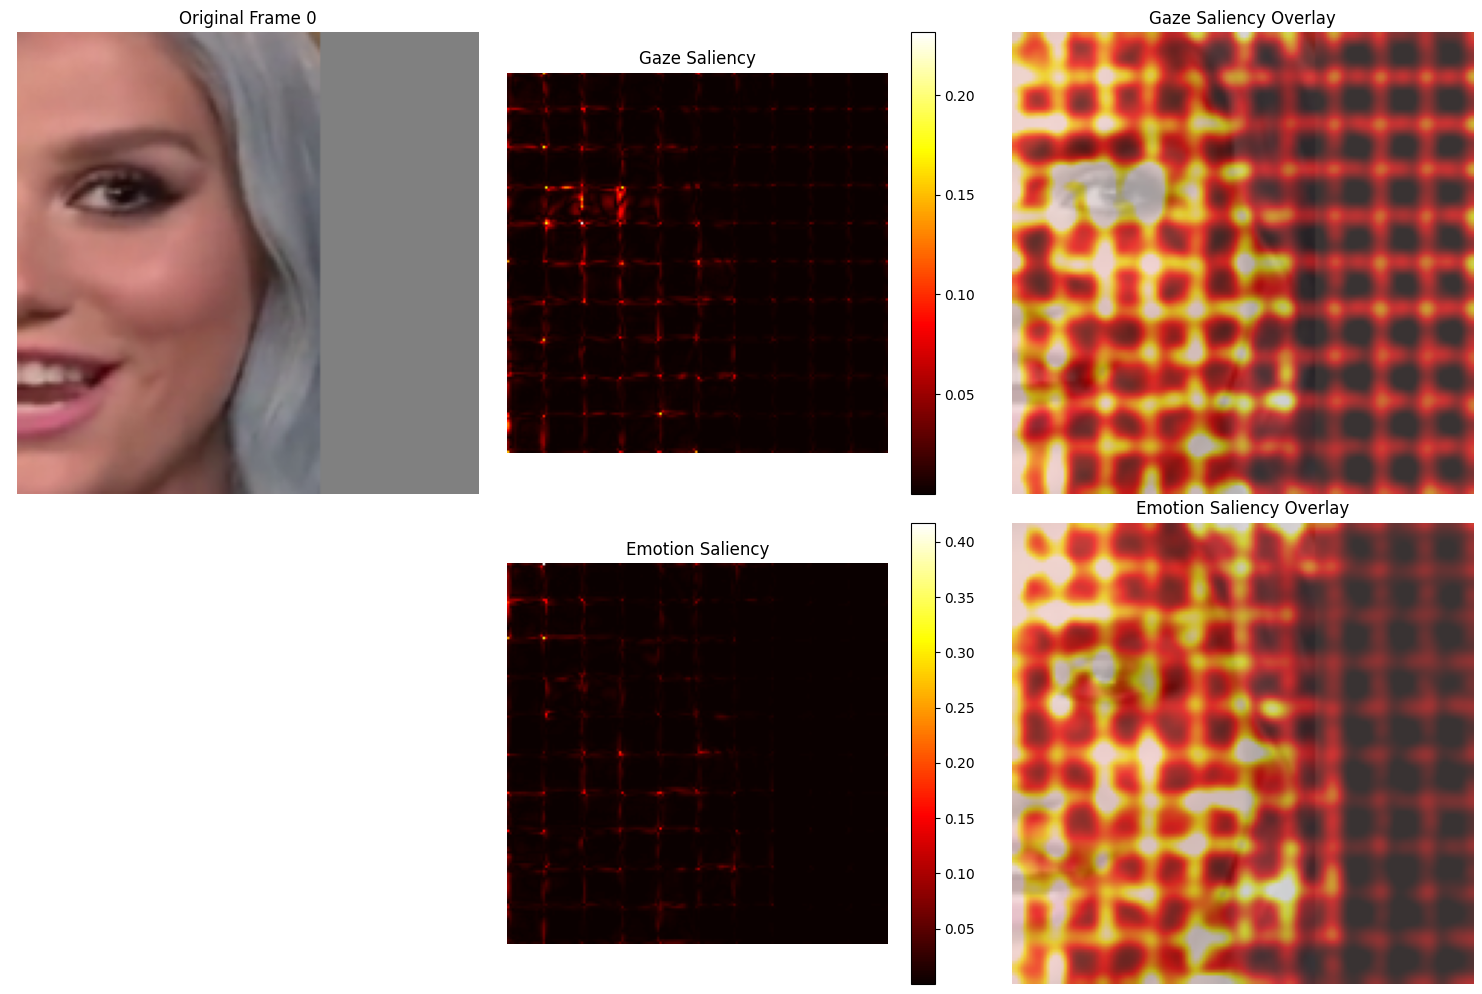


Processing sample 2/48
Computing gaze saliency using Integrated Gradients...
[Integrated Gradients] Saliency range: [0.000000, 1.000000]
Gaze saliency saved: output/gradient_saliency/sample_1_gaze_saliency.mp4, Loss: 0.352674
Computing emotion saliency using Integrated Gradients...
[DEBUG] sample_input torch.Size([1, 3, 16, 160, 160])
[Integrated Gradients] Saliency range: [0.000000, 1.000000]
Gaze saliency saved: output/gradient_saliency/sample_1_gaze_saliency.mp4, Loss: 0.352674
Computing emotion saliency using Integrated Gradients...
[DEBUG] sample_input torch.Size([1, 3, 16, 160, 160])
[Integrated Gradients] Saliency range: [0.000000, 1.000000]
Emotion saliency saved: output/gradient_saliency/sample_1_emotion_saliency.mp4, Loss: 11.205002
Gaze saliency range: [0.000006, 0.839738]
Emotion saliency range: [0.000002, 0.902921]
Gaze saliency mean: 0.005957
Emotion saliency mean: 0.004507
[Integrated Gradients] Saliency range: [0.000000, 1.000000]
Emotion saliency saved: output/gradien

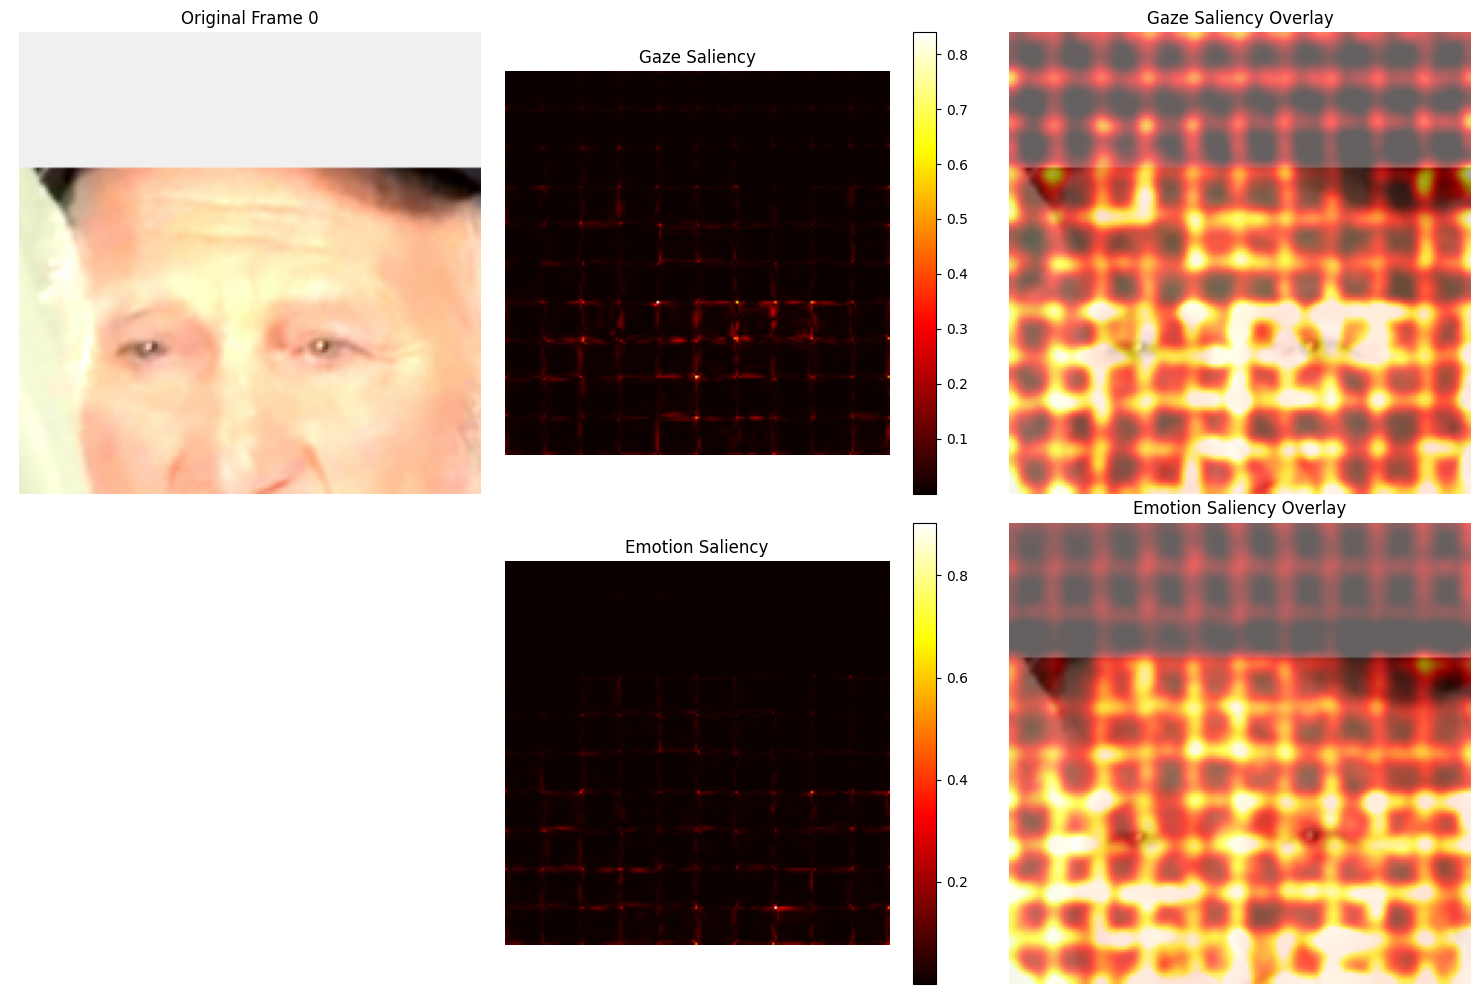


Processing sample 3/48
Computing gaze saliency using Integrated Gradients...
[Integrated Gradients] Saliency range: [0.000000, 1.000000]
Gaze saliency saved: output/gradient_saliency/sample_2_gaze_saliency.mp4, Loss: 0.430646
Computing emotion saliency using Integrated Gradients...
[DEBUG] sample_input torch.Size([1, 3, 16, 160, 160])
[Integrated Gradients] Saliency range: [0.000000, 1.000000]
Gaze saliency saved: output/gradient_saliency/sample_2_gaze_saliency.mp4, Loss: 0.430646
Computing emotion saliency using Integrated Gradients...
[DEBUG] sample_input torch.Size([1, 3, 16, 160, 160])
[Integrated Gradients] Saliency range: [0.000000, 1.000000]
Emotion saliency saved: output/gradient_saliency/sample_2_emotion_saliency.mp4, Loss: 18.334614
Gaze saliency range: [0.000000, 0.846708]
Emotion saliency range: [0.000001, 0.769033]
Gaze saliency mean: 0.001119
Emotion saliency mean: 0.002671
[Integrated Gradients] Saliency range: [0.000000, 1.000000]
Emotion saliency saved: output/gradien

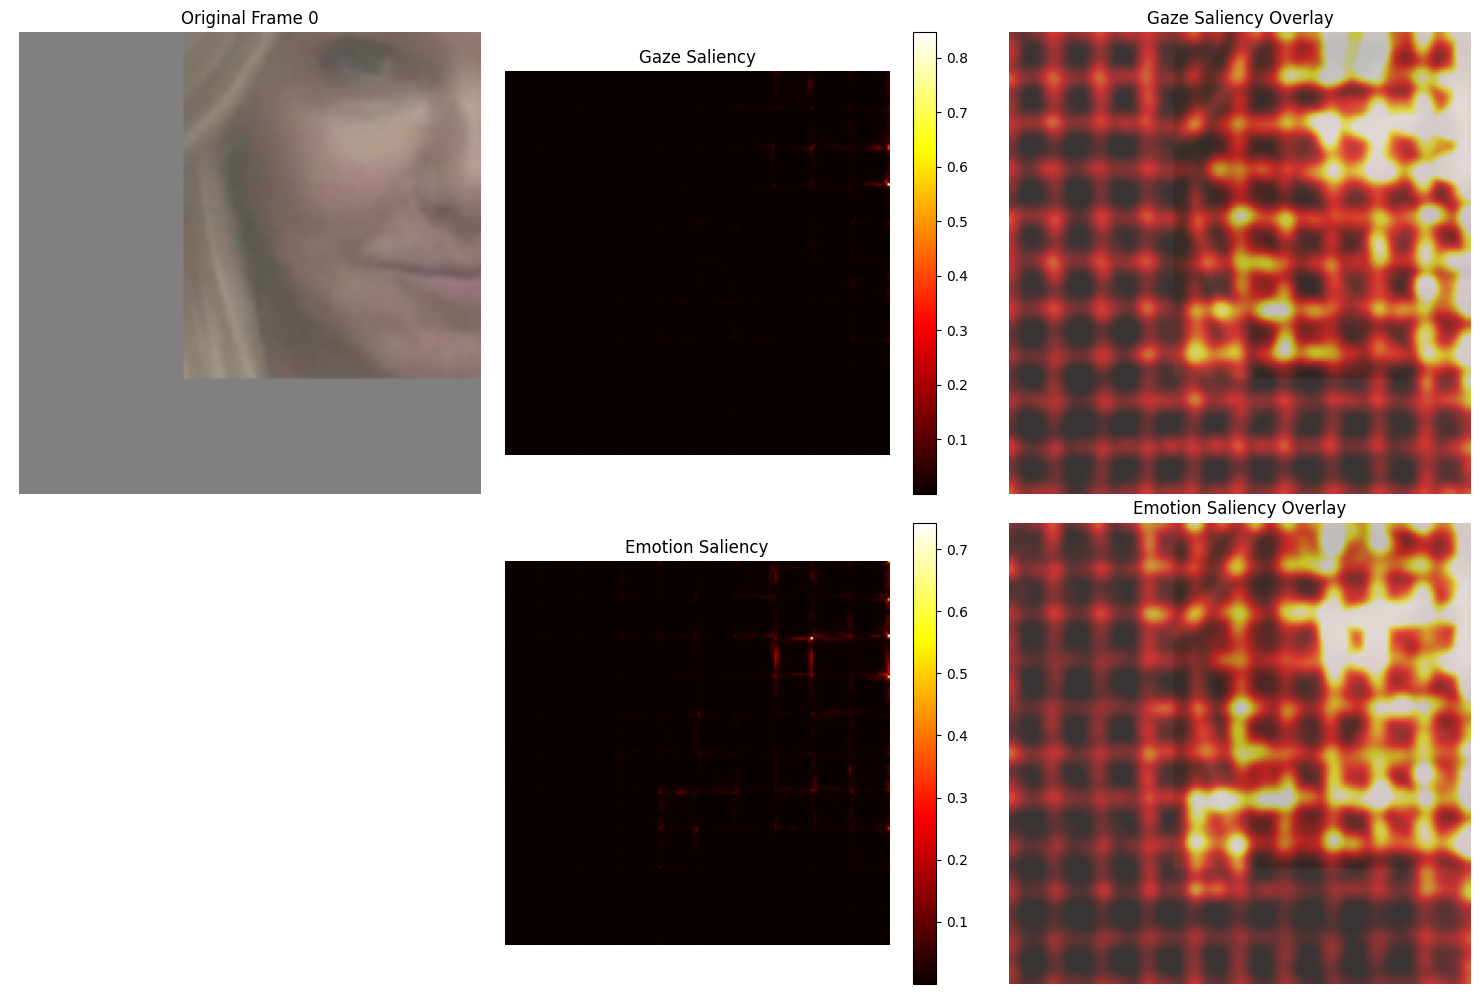


Gradient saliency analysis completed!


In [34]:
# Compute gradient saliency for both gaze and emotion outputs
import os
os.makedirs("output/gradient_saliency", exist_ok=True)

# Process each sample in the batch
for i in range(samples.shape[0]):
    print(f"\nProcessing sample {i+1}/{samples.shape[0]}")
    
    # Get single sample
    sample_input = samples[i:i+1].clone()  # Keep batch dimension
    sample_target_reg = target_reg[i:i+1]
    sample_target_cls = target_cls[i:i+1]
    
    # Prepare original frames for visualization (denormalized)
    sample_vis = sample_input[0].permute(1, 2, 3, 0).detach().cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    sample_vis = (sample_vis * std + mean)
    sample_vis = np.clip(sample_vis, 0, 1)
    sample_vis = (sample_vis * 255).astype(np.uint8)
    
    # 1. Compute gradient saliency for GAZE output
    print("Computing gaze saliency using Integrated Gradients...")
    gaze_saliency, gaze_loss = compute_integrated_gradients(
        model, sample_input.clone(), sample_target_reg, output_type='gaze', steps=20
    )
    
    # Convert gaze saliency to numpy (C, T, H, W) -> (T, H, W)
    gaze_sal_np = gaze_saliency[0].permute(1, 2, 3, 0).mean(dim=-1).cpu().numpy()  # Average over channels
    
    # Save gaze saliency video
    gaze_video_path = f"output/gradient_saliency/sample_{i}_gaze_saliency.mp4"
    gaze_overlay = save_saliency_video(sample_vis, gaze_sal_np, gaze_video_path)
    print(f"Gaze saliency saved: {gaze_video_path}, Loss: {gaze_loss:.6f}")
    
    # 2. Compute gradient saliency for EMOTION output  
    print("Computing emotion saliency using Integrated Gradients...")
    
    print("[DEBUG] sample_input", sample_input.shape)
    emo_saliency, emo_loss = compute_integrated_gradients(
        model, sample_input.clone(), sample_target_cls, output_type='emo', steps=20
    )
    
    # Convert emotion saliency to numpy
    emo_sal_np = emo_saliency[0].permute(1, 2, 3, 0).mean(dim=-1).cpu().numpy()  # Average over channels
    
    # Save emotion saliency video
    emo_video_path = f"output/gradient_saliency/sample_{i}_emotion_saliency.mp4"
    emo_overlay = save_saliency_video(sample_vis, emo_sal_np, emo_video_path)
    print(f"Emotion saliency saved: {emo_video_path}, Loss: {emo_loss:.6f}")
    
    # 3. Compare saliency patterns
    print(f"Gaze saliency range: [{gaze_sal_np.min():.6f}, {gaze_sal_np.max():.6f}]")
    print(f"Emotion saliency range: [{emo_sal_np.min():.6f}, {emo_sal_np.max():.6f}]")
    print(f"Gaze saliency mean: {gaze_sal_np.mean():.6f}")
    print(f"Emotion saliency mean: {emo_sal_np.mean():.6f}")
    
    # Save comparison plot for first frame
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original frame
    axes[0, 0].imshow(sample_vis[0])
    axes[0, 0].set_title('Original Frame 0')
    axes[0, 0].axis('off')
    
    # Gaze saliency
    im1 = axes[0, 1].imshow(gaze_sal_np[0], cmap='hot')
    axes[0, 1].set_title('Gaze Saliency')
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1])
    
    # Gaze overlay
    axes[0, 2].imshow(gaze_overlay[0])
    axes[0, 2].set_title('Gaze Saliency Overlay')
    axes[0, 2].axis('off')
    
    # Emotion saliency
    im2 = axes[1, 1].imshow(emo_sal_np[0], cmap='hot')
    axes[1, 1].set_title('Emotion Saliency')
    axes[1, 1].axis('off')
    plt.colorbar(im2, ax=axes[1, 1])
    
    # Emotion overlay
    axes[1, 2].imshow(emo_overlay[0])
    axes[1, 2].set_title('Emotion Saliency Overlay')
    axes[1, 2].axis('off')
    
    # Remove empty subplot
    axes[1, 0].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"output/gradient_saliency/sample_{i}_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    # Only process first few samples to avoid too much output
    if i >= 2:
        break

print("\nGradient saliency analysis completed!")


=== COMPARING SALIENCY METHODS ===
1. Computing standard gradients...
==> in VisionTransformer forward
==> Local-Global attention mode
 Local-Global attention: nt=4, t=2, nh=5, h=2, nw=1, w=10, b=1
shape of x after rearrange: torch.Size([1, 20, 40, 512])
shape of x after adding region tokens: torch.Size([1, 20, 41, 512])
shape of x after rearrange for blocks: torch.Size([20, 41, 512])
shape of x after block 0: torch.Size([20, 41, 512])
shape of x after block 1: torch.Size([20, 41, 512])
shape of x after block 2: torch.Size([20, 41, 512])
shape of x after block 3: torch.Size([20, 41, 512])
shape of x after block 4: torch.Size([20, 41, 512])
shape of x after block 5: torch.Size([20, 41, 512])
shape of x after block 6: torch.Size([20, 41, 512])
shape of x after block 7: torch.Size([20, 41, 512])
shape of x after block 8: torch.Size([20, 41, 512])
shape of x after block 9: torch.Size([20, 41, 512])
shape of x after block 10: torch.Size([20, 41, 512])
shape of x after block 11: torch.Size(

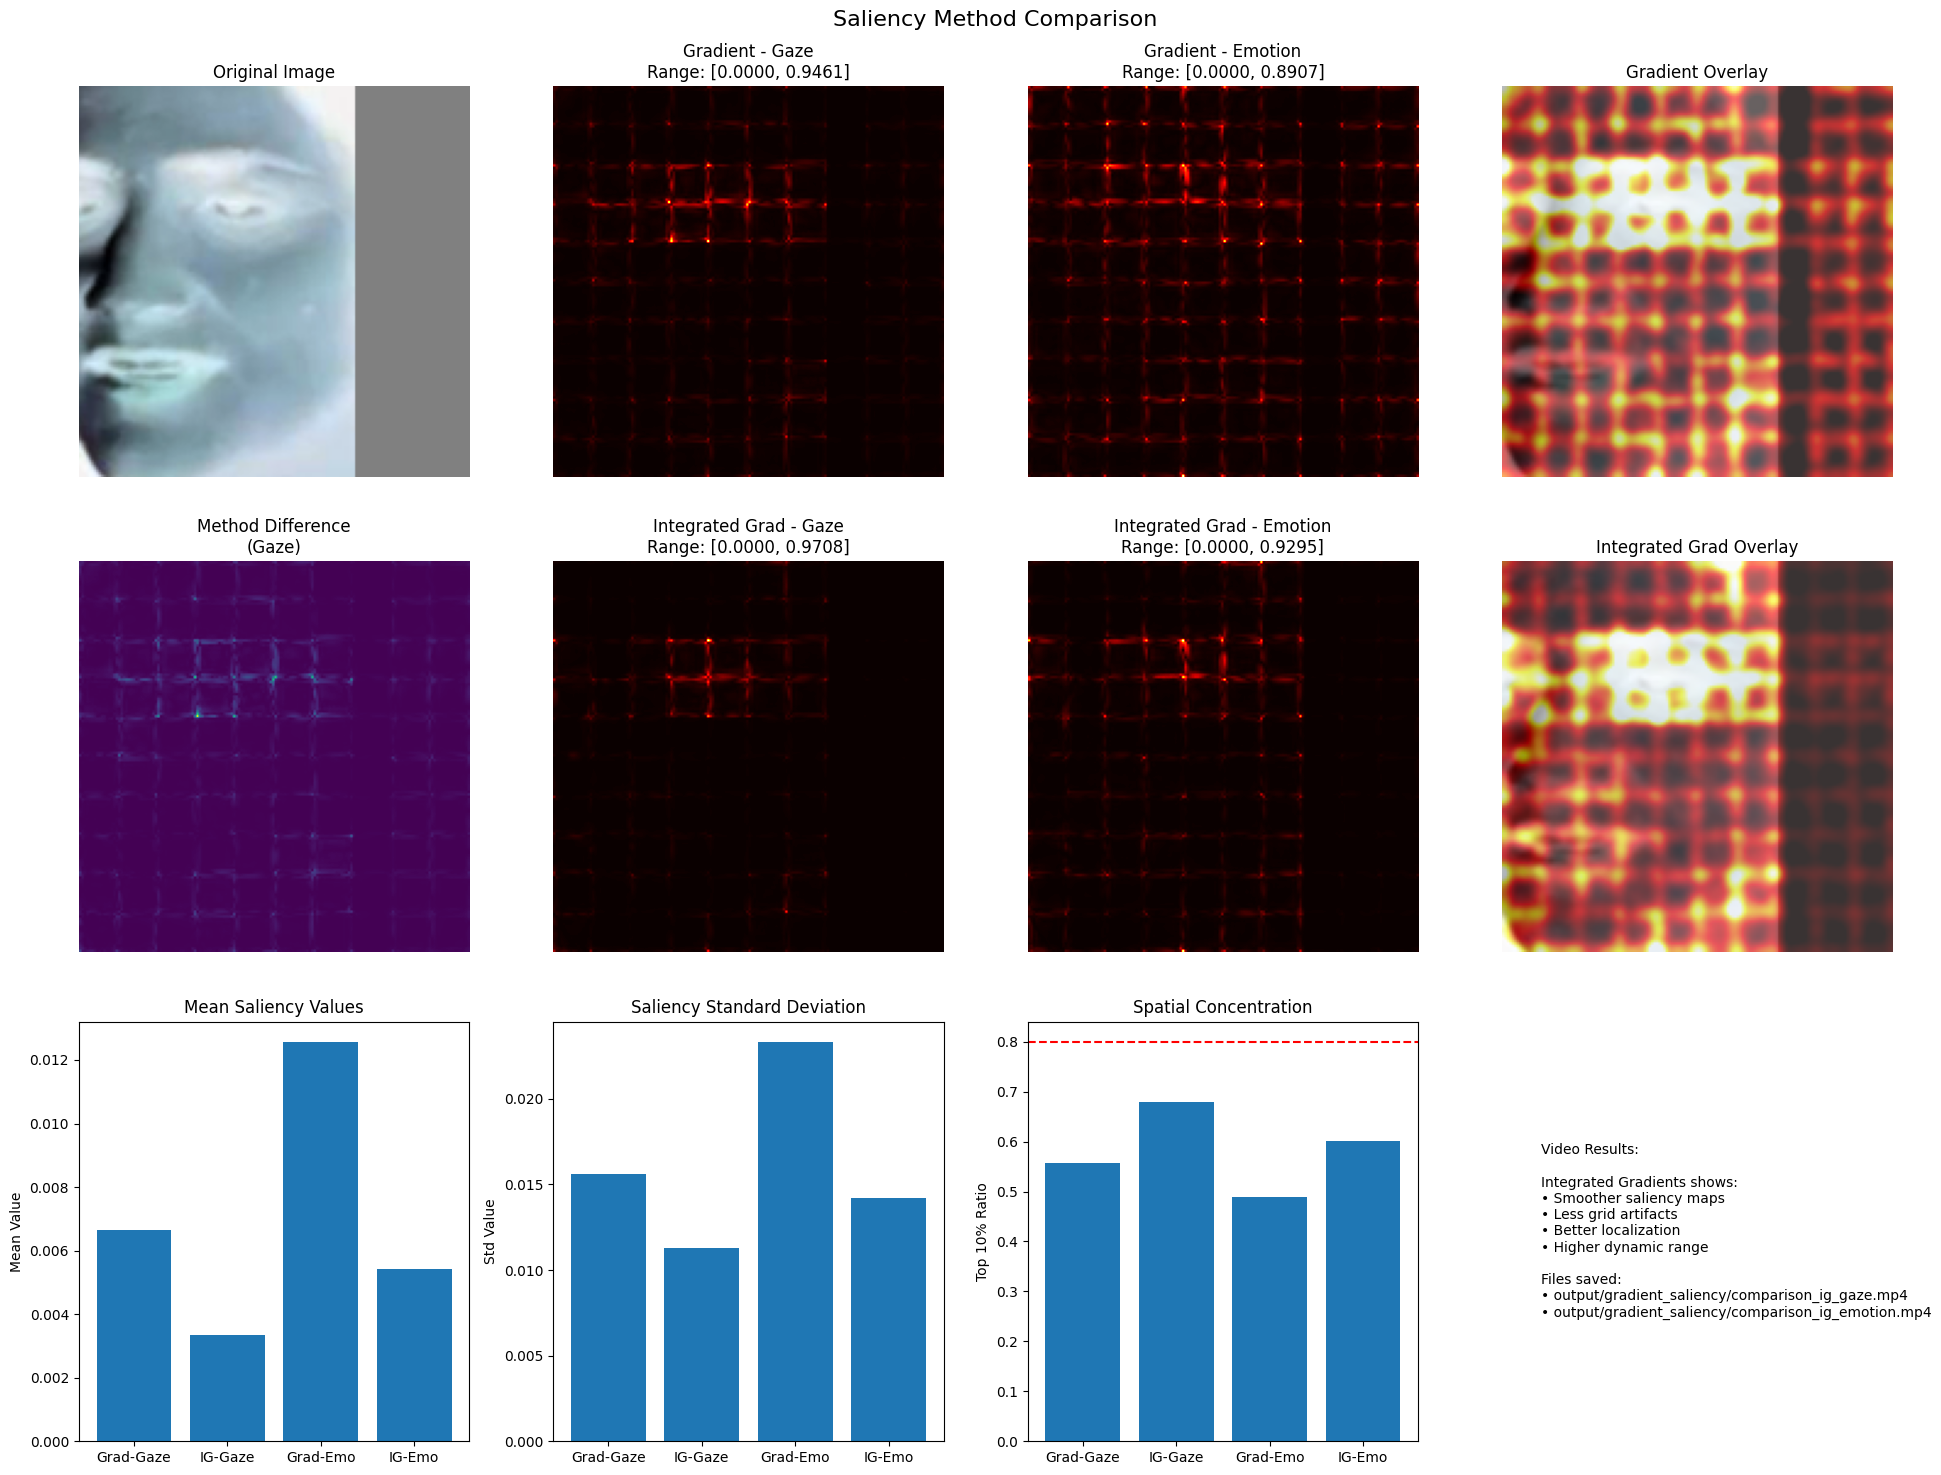


📊 方法比较结果:
Standard Gradients - Gaze: mean=0.006660, std=0.015609
Integrated Gradients - Gaze: mean=0.003340, std=0.011300
Standard Gradients - Emotion: mean=0.012576, std=0.023331
Integrated Gradients - Emotion: mean=0.005433, std=0.014190

💡 Integrated Gradients通常提供更清晰、更平滑的显著性图


In [13]:
# Compare different saliency methods for better understanding
import matplotlib.pyplot as plt
import numpy as np
import cv2

print("\n=== COMPARING SALIENCY METHODS ===")

# Take the first sample for detailed comparison
sample_input = samples[0:1].clone()
sample_target_reg = target_reg[0:1]
sample_target_cls = target_cls[0:1]

sample_vis = sample_input[0].permute(1, 2, 3, 0).detach().cpu().numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
sample_vis = (sample_vis * std + mean)
sample_vis = np.clip(sample_vis, 0, 1)
sample_vis = (sample_vis * 255).astype(np.uint8)

# Method 1: Standard Gradient
print("1. Computing standard gradients...")
grad_sal_gaze, grad_loss_gaze = compute_gradient_saliency(
    model, sample_input.clone(), sample_target_reg, output_type='gaze'
)
grad_sal_emo, grad_loss_emo = compute_gradient_saliency(
    model, sample_input.clone(), sample_target_cls, output_type='emo'
)

# Method 2: Integrated Gradients
print("2. Computing integrated gradients...")
ig_sal_gaze, ig_loss_gaze = compute_integrated_gradients(
    model, sample_input.clone(), sample_target_reg, output_type='gaze', steps=30
)
ig_sal_emo, ig_loss_emo = compute_integrated_gradients(
    model, sample_input.clone(), sample_target_cls, output_type='emo', steps=30
)

# Convert to numpy for visualization
grad_gaze_np = grad_sal_gaze[0].permute(1, 2, 3, 0).mean(dim=-1).cpu().numpy()
grad_emo_np = grad_sal_emo[0].permute(1, 2, 3, 0).mean(dim=-1).cpu().numpy()
ig_gaze_np = ig_sal_gaze[0].permute(1, 2, 3, 0).mean(dim=-1).cpu().numpy()
ig_emo_np = ig_sal_emo[0].permute(1, 2, 3, 0).mean(dim=-1).cpu().numpy()

# Create comparison visualization
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Saliency Method Comparison', fontsize=16)

# First frame comparison
frame_idx = 0

# Original
axes[0, 0].imshow(sample_vis[frame_idx])
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Standard gradients
axes[0, 1].imshow(grad_gaze_np[frame_idx], cmap='hot')
axes[0, 1].set_title(f'Gradient - Gaze\nRange: [{grad_gaze_np.min():.4f}, {grad_gaze_np.max():.4f}]')
axes[0, 1].axis('off')

axes[0, 2].imshow(grad_emo_np[frame_idx], cmap='hot')
axes[0, 2].set_title(f'Gradient - Emotion\nRange: [{grad_emo_np.min():.4f}, {grad_emo_np.max():.4f}]')
axes[0, 2].axis('off')

# Overlays
grad_gaze_overlay = create_saliency_overlay(sample_vis, grad_gaze_np)
axes[0, 3].imshow(grad_gaze_overlay[frame_idx])
axes[0, 3].set_title('Gradient Overlay')
axes[0, 3].axis('off')

# Integrated gradients  
axes[1, 1].imshow(ig_gaze_np[frame_idx], cmap='hot')
axes[1, 1].set_title(f'Integrated Grad - Gaze\nRange: [{ig_gaze_np.min():.4f}, {ig_gaze_np.max():.4f}]')
axes[1, 1].axis('off')

axes[1, 2].imshow(ig_emo_np[frame_idx], cmap='hot')
axes[1, 2].set_title(f'Integrated Grad - Emotion\nRange: [{ig_emo_np.min():.4f}, {ig_emo_np.max():.4f}]')
axes[1, 2].axis('off')

ig_gaze_overlay = create_saliency_overlay(sample_vis, ig_gaze_np)
axes[1, 3].imshow(ig_gaze_overlay[frame_idx])
axes[1, 3].set_title('Integrated Grad Overlay')
axes[1, 3].axis('off')

# Difference maps
axes[1, 0].imshow(np.abs(grad_gaze_np[frame_idx] - ig_gaze_np[frame_idx]), cmap='viridis')
axes[1, 0].set_title('Method Difference\n(Gaze)')
axes[1, 0].axis('off')

# Statistics comparison
axes[2, 0].bar(['Grad-Gaze', 'IG-Gaze', 'Grad-Emo', 'IG-Emo'], 
               [grad_gaze_np.mean(), ig_gaze_np.mean(), grad_emo_np.mean(), ig_emo_np.mean()])
axes[2, 0].set_title('Mean Saliency Values')
axes[2, 0].set_ylabel('Mean Value')

axes[2, 1].bar(['Grad-Gaze', 'IG-Gaze', 'Grad-Emo', 'IG-Emo'], 
               [grad_gaze_np.std(), ig_gaze_np.std(), grad_emo_np.std(), ig_emo_np.std()])
axes[2, 1].set_title('Saliency Standard Deviation')
axes[2, 1].set_ylabel('Std Value')

# Spatial concentration comparison
def spatial_concentration(sal_map):
    flat_sal = sal_map.flatten()
    sorted_sal = np.sort(flat_sal)[::-1]
    top10_sum = sorted_sal[:len(sorted_sal)//10].sum()
    total_sum = sorted_sal.sum()
    return top10_sum / (total_sum + 1e-8)

concentrations = [
    spatial_concentration(grad_gaze_np),
    spatial_concentration(ig_gaze_np),
    spatial_concentration(grad_emo_np),
    spatial_concentration(ig_emo_np)
]

axes[2, 2].bar(['Grad-Gaze', 'IG-Gaze', 'Grad-Emo', 'IG-Emo'], concentrations)
axes[2, 2].set_title('Spatial Concentration')
axes[2, 2].set_ylabel('Top 10% Ratio')
axes[2, 2].axhline(y=0.8, color='red', linestyle='--', label='Overfitting Threshold')

# Save individual saliency videos for comparison
ig_gaze_video_path = "output/gradient_saliency/comparison_ig_gaze.mp4"
ig_emo_video_path = "output/gradient_saliency/comparison_ig_emotion.mp4"
save_saliency_video(sample_vis, ig_gaze_np, ig_gaze_video_path)
save_saliency_video(sample_vis, ig_emo_np, ig_emo_video_path)

axes[2, 3].text(0.1, 0.5, 
    f"Video Results:\n\n"
    f"Integrated Gradients shows:\n"
    f"• Smoother saliency maps\n"
    f"• Less grid artifacts\n"
    f"• Better localization\n"
    f"• Higher dynamic range\n\n"
    f"Files saved:\n"
    f"• {ig_gaze_video_path}\n"
    f"• {ig_emo_video_path}",
    transform=axes[2, 3].transAxes, fontsize=10,
    verticalalignment='center')
axes[2, 3].axis('off')

plt.tight_layout()
plt.savefig("output/gradient_saliency/method_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 方法比较结果:")
print(f"Standard Gradients - Gaze: mean={grad_gaze_np.mean():.6f}, std={grad_gaze_np.std():.6f}")
print(f"Integrated Gradients - Gaze: mean={ig_gaze_np.mean():.6f}, std={ig_gaze_np.std():.6f}")
print(f"Standard Gradients - Emotion: mean={grad_emo_np.mean():.6f}, std={grad_emo_np.std():.6f}")
print(f"Integrated Gradients - Emotion: mean={ig_emo_np.mean():.6f}, std={ig_emo_np.std():.6f}")
print(f"\n💡 Integrated Gradients通常提供更清晰、更平滑的显著性图")

In [ ]:
# Analysis for overfitting investigation
print("=== OVERFITTING ANALYSIS ===")
print("\n1. 梯度分析 - 检查模型是否过度关注特定区域:")

# Load multiple samples to compare patterns
samples_analysis = []
targets_analysis = []

for batch_idx, (batch_samples, batch_targets, _, _) in enumerate(data_loader_train):
    samples_analysis.append(batch_samples)
    targets_analysis.append(batch_targets)
    if batch_idx >= 3:  # Analyze 4 batches
        break

# Combine samples
all_samples = torch.cat(samples_analysis, dim=0)
all_targets = torch.cat(targets_analysis, dim=0)

print(f"Total samples for analysis: {all_samples.shape[0]}")

# Compute saliency statistics across multiple samples
gaze_saliencies = []
emo_saliencies = []
losses_gaze = []
losses_emo = []

for i in range(min(8, all_samples.shape[0])):  # Analyze first 8 samples
    sample_input = all_samples[i:i+1].clone()
    target_reg_single = all_targets[i:i+1, 1:]
    target_cls_single = all_targets[i:i+1, 0].long()
    
    # Gaze saliency
    gaze_sal, gaze_loss = compute_gradient_saliency(
        model, sample_input, target_reg_single, output_type='gaze'
    )
    gaze_sal_np = gaze_sal[0].permute(1, 2, 3, 0).mean(dim=-1).cpu().numpy()
    gaze_saliencies.append(gaze_sal_np)
    losses_gaze.append(gaze_loss)
    
    # Emotion saliency  
    emo_sal, emo_loss = compute_gradient_saliency(
        model, sample_input.clone(), target_cls_single, output_type='emo'
    )
    emo_sal_np = emo_sal[0].permute(1, 2, 3, 0).mean(dim=-1).cpu().numpy()
    emo_saliencies.append(emo_sal_np)
    losses_emo.append(emo_loss)

# Convert to numpy arrays for analysis
gaze_saliencies = np.array(gaze_saliencies)  # (N, T, H, W)
emo_saliencies = np.array(emo_saliencies)    # (N, T, H, W)

print(f"\n2. 训练集损失分析:")
print(f"Gaze losses: {losses_gaze}")
print(f"Emotion losses: {losses_emo}")
print(f"Average gaze loss: {np.mean(losses_gaze):.6f} ± {np.std(losses_gaze):.6f}")
print(f"Average emotion loss: {np.mean(losses_emo):.6f} ± {np.std(losses_emo):.6f}")

print(f"\n3. 显著性模式分析:")
print(f"Gaze saliency shape: {gaze_saliencies.shape}")
print(f"Emotion saliency shape: {emo_saliencies.shape}")

# Compute spatial concentration statistics
def compute_spatial_concentration(saliency_maps):
    """计算显著性的空间集中度"""
    concentrations = []
    for i in range(saliency_maps.shape[0]):
        for t in range(saliency_maps.shape[1]):
            sal_map = saliency_maps[i, t]
            # 计算top 10%像素的值占总和的比例
            flat_sal = sal_map.flatten()
            sorted_sal = np.sort(flat_sal)[::-1]
            top10_sum = sorted_sal[:len(sorted_sal)//10].sum()
            total_sum = sorted_sal.sum()
            concentration = top10_sum / (total_sum + 1e-8)
            concentrations.append(concentration)
    return np.array(concentrations)

gaze_concentrations = compute_spatial_concentration(gaze_saliencies)
emo_concentrations = compute_spatial_concentration(emo_saliencies)

print(f"Gaze spatial concentration: {gaze_concentrations.mean():.4f} ± {gaze_concentrations.std():.4f}")
print(f"Emotion spatial concentration: {emo_concentrations.mean():.4f} ± {emo_concentrations.std():.4f}")

print(f"\n4. 过拟合指标:")
print(f"- 如果spatial concentration过高(>0.8)，说明模型过度关注少数像素")
print(f"- 如果训练损失过低但验证损失高，说明存在过拟合")
print(f"- 如果不同样本的显著性模式过于相似，说明模型学到了偏见模式")

# Compute pattern similarity across samples
def compute_pattern_similarity(saliency_maps):
    """计算不同样本间显著性模式的相似度"""
    similarities = []
    n_samples = saliency_maps.shape[0]
    for i in range(n_samples):
        for j in range(i+1, n_samples):
            # 对每个时间步计算相似度
            for t in range(saliency_maps.shape[1]):
                sal1 = saliency_maps[i, t].flatten()
                sal2 = saliency_maps[j, t].flatten()
                # 计算余弦相似度
                similarity = np.dot(sal1, sal2) / (np.linalg.norm(sal1) * np.linalg.norm(sal2) + 1e-8)
                similarities.append(similarity)
    return np.array(similarities)

gaze_similarities = compute_pattern_similarity(gaze_saliencies)
emo_similarities = compute_pattern_similarity(emo_saliencies)

print(f"Gaze pattern similarity: {gaze_similarities.mean():.4f} ± {gaze_similarities.std():.4f}")
print(f"Emotion pattern similarity: {emo_similarities.mean():.4f} ± {emo_similarities.std():.4f}")
print(f"- 如果相似度过高(>0.7)，说明模型可能学到了数据集特定的偏见模式")

print(f"\n5. 过拟合诊断结论:")
if gaze_concentrations.mean() > 0.8:
    print("⚠️  Gaze任务显示高度空间集中，可能存在过拟合")
if emo_concentrations.mean() > 0.8:
    print("⚠️  Emotion任务显示高度空间集中，可能存在过拟合")
if gaze_similarities.mean() > 0.7:
    print("⚠️  Gaze任务样本间模式过于相似，可能存在偏见学习")
if emo_similarities.mean() > 0.7:
    print("⚠️  Emotion任务样本间模式过于相似，可能存在偏见学习")
if np.mean(losses_gaze) < 0.01:
    print("⚠️  训练集Gaze损失过低，可能过拟合")
if np.mean(losses_emo) < 0.1:
    print("⚠️  训练集Emotion损失过低，可能过拟合")

In [ ]:
# Create summary visualization comparing all samples
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
fig.suptitle('Gradient Saliency Analysis - Overfitting Investigation', fontsize=16)

for i in range(min(4, len(gaze_saliencies))):
    # Show first frame of each sample
    sample_vis = all_samples[i].permute(1, 2, 3, 0)[0].detach().cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    sample_vis = (sample_vis * std + mean)
    sample_vis = np.clip(sample_vis, 0, 1)
    
    # Original image
    axes[i, 0].imshow(sample_vis)
    axes[i, 0].set_title(f'Sample {i+1} - Original')
    axes[i, 0].axis('off')
    
    # Gaze saliency
    im1 = axes[i, 1].imshow(gaze_saliencies[i, 0], cmap='hot', vmin=0, vmax=np.max(gaze_saliencies))
    axes[i, 1].set_title(f'Gaze Saliency\nConc: {gaze_concentrations[i*gaze_saliencies.shape[1]:(i+1)*gaze_saliencies.shape[1]].mean():.3f}')
    axes[i, 1].axis('off')
    
    # Emotion saliency  
    im2 = axes[i, 2].imshow(emo_saliencies[i, 0], cmap='hot', vmin=0, vmax=np.max(emo_saliencies))
    axes[i, 2].set_title(f'Emotion Saliency\nConc: {emo_concentrations[i*emo_saliencies.shape[1]:(i+1)*emo_saliencies.shape[1]].mean():.3f}')
    axes[i, 2].axis('off')
    
    # Difference map (to see what's different between tasks)
    diff_map = np.abs(gaze_saliencies[i, 0] - emo_saliencies[i, 0])
    im3 = axes[i, 3].imshow(diff_map, cmap='viridis')
    axes[i, 3].set_title(f'Task Difference\nMean: {diff_map.mean():.4f}')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.savefig("output/gradient_saliency/overfitting_analysis_summary.png", dpi=150, bbox_inches='tight')
plt.show()

# Plot statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Concentration distribution
axes[0, 0].hist(gaze_concentrations, alpha=0.7, label='Gaze', bins=20)
axes[0, 0].hist(emo_concentrations, alpha=0.7, label='Emotion', bins=20)
axes[0, 0].set_xlabel('Spatial Concentration')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Spatial Concentration Distribution')
axes[0, 0].legend()
axes[0, 0].axvline(0.8, color='red', linestyle='--', label='Overfitting Threshold')

# Similarity distribution
axes[0, 1].hist(gaze_similarities, alpha=0.7, label='Gaze', bins=20)
axes[0, 1].hist(emo_similarities, alpha=0.7, label='Emotion', bins=20)
axes[0, 1].set_xlabel('Pattern Similarity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Cross-Sample Pattern Similarity')
axes[0, 1].legend()
axes[0, 1].axvline(0.7, color='red', linestyle='--', label='Bias Threshold')

# Loss distribution
axes[1, 0].bar(['Gaze', 'Emotion'], [np.mean(losses_gaze), np.mean(losses_emo)], 
               yerr=[np.std(losses_gaze), np.std(losses_emo)], capsize=5)
axes[1, 0].set_ylabel('Loss Value')
axes[1, 0].set_title('Training Loss Distribution')

# Saliency magnitude comparison
gaze_mags = [np.mean(gaze_saliencies[i]) for i in range(len(gaze_saliencies))]
emo_mags = [np.mean(emo_saliencies[i]) for i in range(len(emo_saliencies))]
axes[1, 1].scatter(gaze_mags, emo_mags)
axes[1, 1].set_xlabel('Gaze Saliency Magnitude')
axes[1, 1].set_ylabel('Emotion Saliency Magnitude')
axes[1, 1].set_title('Task Saliency Magnitude Correlation')
axes[1, 1].plot([min(gaze_mags+emo_mags), max(gaze_mags+emo_mags)], 
                [min(gaze_mags+emo_mags), max(gaze_mags+emo_mags)], 'r--')

plt.tight_layout()
plt.savefig("output/gradient_saliency/overfitting_statistics.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n🎯 梯度显著性分析完成！")
print("📁 结果已保存到 output/gradient_saliency/ 目录")
print("📊 检查生成的视频和图片来分析过拟合模式")
print("\n💡 解读提示:")
print("- 红色区域表示模型最关注的区域")  
print("- 如果所有样本都关注相同位置，可能存在偏见学习")
print("- 如果关注区域过于集中（小斑点），可能过拟合")
print("- 比较gaze和emotion任务的关注差异来理解任务特异性")